In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spectral.io import envi
from spectral.io.envi import read_envi_header, write_envi_header
from glob import glob
import rasterio
from rasterio.windows import from_bounds
from scipy.ndimage import map_coordinates
from scipy import ndimage

from utilities import *

In [ ]:
# figure out how to reconstruct raw space obs from obs_ort, GLT

In [2]:
home = '/store/carroll/col/2018/'
rmbl = '/store/carroll/col/2018/raw/rmbl/' # reprocessed data from Tristan
out = home+'test_roi/'

flight = 'NIS01_20180619_172934' # aspen subset

buf = 25

In [17]:
# # # add byte order to all new data associated w this flightline
# fps = glob(rmbl + f'*/*{flight}*.hdr')
# for fp in fps:
#     add_byte_order(fp)

In [3]:
# load data
fp_obs = glob(rmbl+f'*/{flight}_rdn_obs_ort.hdr')[0]
fp_glt = glob(rmbl+f'*/{flight}_rdn_ort_glt.hdr')[0]
fp_rdn = glob(rmbl+f'*/{flight}_rdn.hdr')[0]

obs_ort = envi.open(fp_obs).open_memmap(interleave='bip')
glt_ort = envi.open(fp_glt).open_memmap(interleave='bip').copy().astype(float)
rdn_raw = envi.open(fp_rdn).open_memmap(interleave='bip')

obs_ort.shape, glt_ort.shape, rdn_raw.shape

((21012, 1598, 11), (21012, 1598, 2), (38610, 598, 426))

In [4]:
def get_raw_obs(fp_obs_ort, fp_glt, fp_rdn):
    """
    Derive raw-space obs data from orthorectified obs data and GLT
    """
    # load data
    obs_ort = envi.open(fp_obs).open_memmap(interleave='bip')
    glt_ort = envi.open(fp_glt).open_memmap(interleave='bip').copy().astype(float)
    rdn_raw = envi.open(fp_rdn).open_memmap(interleave='bip')

    # generate empty array with raw_space shape
    obs_raw = np.full((rdn_raw.shape[0], rdn_raw.shape[1], obs_ort.shape[2]), np.nan, dtype=obs_ort.dtype)
    
    # mask glt_ort
    glt_ort[glt_ort<=0] = np.nan

    # raw positions from GLT
    col_raw = glt_ort[..., 0]
    row_raw = glt_ort[..., 1]
    
    # create valid mask
    valid = np.isfinite(col_raw) & np.isfinite(row_raw)
    
    # convert to int (assuming 1-based indexing in GLT)
    row_idx = row_raw[valid].astype(int) - 1
    col_idx = col_raw[valid].astype(int) - 1
    
    # flip row, col idx to match raw-space coordinate system
    row_idx_flipped = (obs_raw.shape[0] - 1) - row_idx
    col_idx_flipped = (obs_raw.shape[1] - 1) - col_idx
    
    # grab all valid ortho values
    vals = obs_ort[valid, :]   # shape: (n_valid_pixels, bands)
    
    # assign to raw array
    obs_raw[row_idx_flipped, col_idx_flipped, :] = vals
    
    # fill blank values
    rows, cols, bands = obs_raw.shape
    
    # Copy array for output
    obs_filled = obs_raw.copy()
    
    # interpolate, fill by band
    for b in range(bands):
        band = obs_raw[..., b]
        mask = np.isnan(band)
        # Get indices of nearest non-NaN pixels
        idx = ndimage.distance_transform_edt(mask, return_distances=False, return_indices=True)
        obs_filled[..., b] = band[tuple(idx)]

    return obs_filled

In [5]:
obs = get_raw_obs(fp_obs, fp_glt, fp_rdn)

0
1
2
3
4
5
6
7
8
9
10


In [11]:
# generate empty array with raw_space shape
obs_raw = np.full((rdn_raw.shape[0], rdn_raw.shape[1], obs_ort.shape[2]), np.nan, dtype=obs_ort.dtype)
print(obs_raw.shape)

# mask glt_ort
glt_ort[glt_ort<=0] = np.nan

(38610, 598, 11)


In [12]:
# Extract raw positions from GLT
col_raw = glt_ort[..., 0]
row_raw = glt_ort[..., 1]

# Create valid mask
valid = np.isfinite(col_raw) & np.isfinite(row_raw)

# Convert to int (assuming 1-based indexing in GLT)
row_idx = row_raw[valid].astype(int) - 1
col_idx = col_raw[valid].astype(int) - 1

# flip row, col idx to match raw-space coordinate system
row_idx_flipped = (obs_raw.shape[0] - 1) - row_idx
col_idx_flipped = (obs_raw.shape[1] - 1) - col_idx

# Grab all valid ortho values at once
vals = obs_ort[valid, :]   # shape: (n_valid_pixels, bands)

# Assign to raw array
obs_raw[row_idx_flipped, col_idx_flipped, :] = vals

# # now interpolate (before figuring out rotation)
# rows, cols, bands = obs_raw.shape

# # Copy array for output
# obs_filled = obs_raw.copy()

# # interpolate, fill by band
# for b in range(bands):
#     print(b)
#     band = obs_raw[..., b]
#     mask = np.isnan(band)
#     # Get indices of nearest non-NaN pixels
#     idx = ndimage.distance_transform_edt(mask, return_distances=False, return_indices=True)
#     obs_filled[..., b] = band[tuple(idx)]


In [13]:
rows, cols, bands = obs_raw.shape
x = np.arange(cols)
y = np.arange(rows)

filled = obs_raw.copy()

In [14]:
# actual interpolation... oh yeah this is much faster

for b in range(bands):
    print(b)
    band = obs_raw[..., b]
    mask = ~np.isnan(band)
    
    interp = RegularGridInterpolator(
        (y, x),
        np.nan_to_num(band),  # replace NaNs temporarily
        bounds_error=False, fill_value=None
    )
    
    nan_y, nan_x = np.where(np.isnan(band))
    filled_vals = interp(np.column_stack((nan_y, nan_x)))
    filled[nan_y, nan_x, b] = filled_vals

0
1
2
3
4
5
6
7
8
9
10


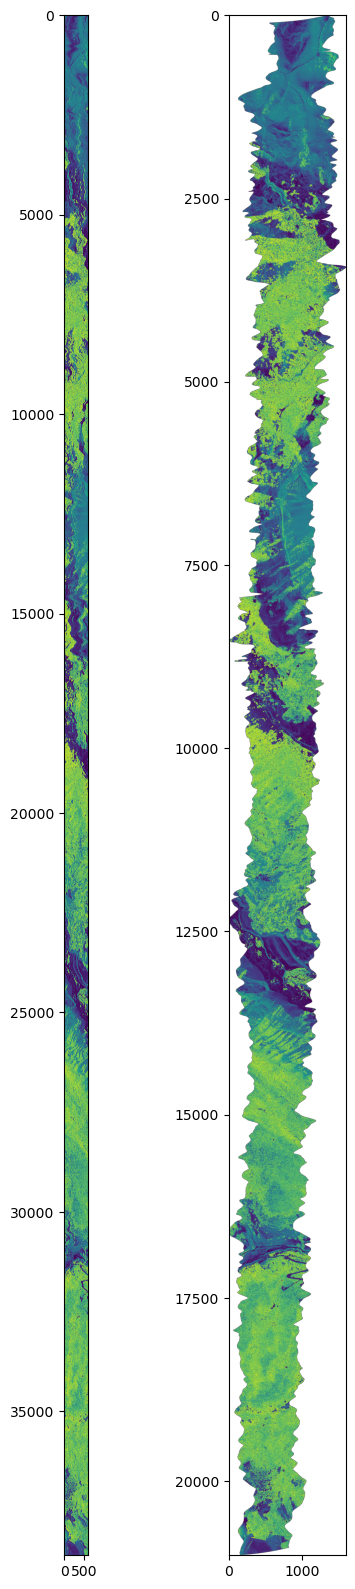

In [6]:
# check if it worked
plt_ = obs_ort[...,6].copy()
plt_[plt_==-9999] = np.nan

fig, axs = plt.subplots(ncols=2, figsize=(5,20))
axs[0].imshow(obs[...,6])
axs[1].imshow(plt_)
plt.show()

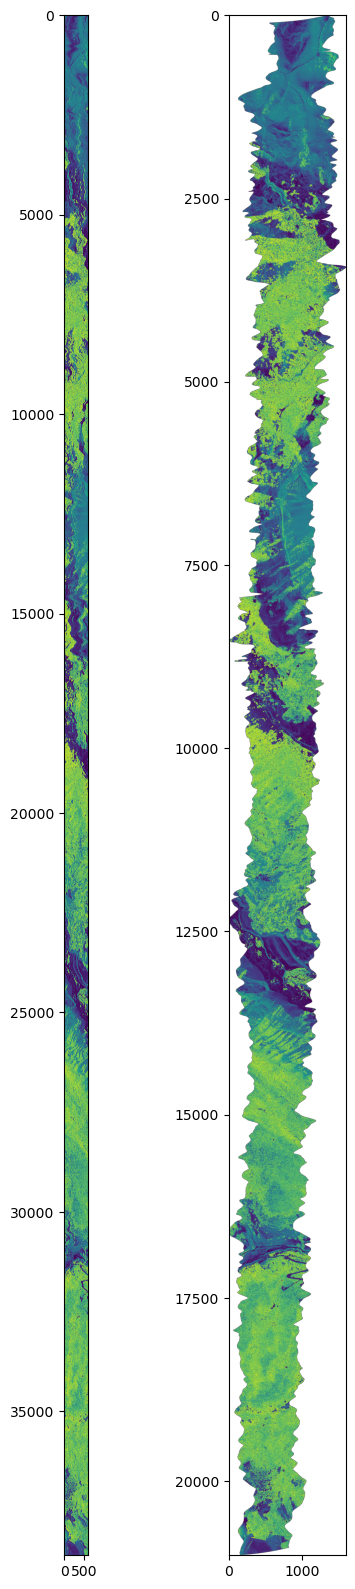

In [7]:
# check if it worked
plt_ = obs_ort[...,6].copy()
plt_[plt_==-9999] = np.nan

fig, axs = plt.subplots(ncols=2, figsize=(5,20))
axs[0].imshow(obs_filled[...,6])
axs[1].imshow(plt_)
plt.show()